In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
from scipy.ndimage import zoom

import monai
from monai.networks.nets import ResNet, DenseNet121
from monai.networks.nets.resnet import ResNetBlock
from monai.transforms import (
    Compose, EnsureChannelFirstd, EnsureTyped,
    LoadImaged, NormalizeIntensityd, Resized,
)
from monai.visualize import GradCAM

print(f"PyTorch  : {torch.__version__}")
print(f"MONAI    : {monai.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device   : {device}")

PyTorch  : 2.10.0+cu126
MONAI    : 1.5.2
Device   : cuda


In [2]:
MODEL_PATH   = r"..\\runs\\BrainIAC_best\\best_BrainIAC.pth"
NII_PATH     = r"..\\ADHD_BIDS\\sub-1017176\\anat\\1017176_T1w.nii.gz"
CHOSEN_MODEL = "BrainIAC"
TRUE_LABEL   = None

NUM_CLASSES  = 2
DROPOUT_RATE = 0.5
TARGET_SIZE  = (96,96,96) if CHOSEN_MODEL == "BrainIAC" else (121, 128, 121)
BRAINIAC_UNFREEZE_MODE = "full"

HEATMAP_CMAP = "jet"
HEATMAP_ALPHA = 0.45
SAVE_DPI     = 150

GRADCAM_LAYERS = {
    "ResNet18":   "layer4.1.conv2",
    "ResNet50":   "layer4.2.conv2",
    "DenseNet121":"features.denseblock4.denselayer16.layers.conv2",
    "SFCN":       "features.5.2",
    "BrainIAC":   None,
    "AnatCL":     "backbone.encoder.layer4",
}
GRADCAM_LAYER = GRADCAM_LAYERS.get(CHOSEN_MODEL)


In [3]:
class SFCN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            self._block(1,32), self._block(32,64), self._block(64,128),
            self._block(128,256), self._block(256,256), self._block(256,64,pool=False),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(p=DROPOUT_RATE), nn.Conv3d(64, num_classes, kernel_size=1)
        )
    def _block(self, i, o, pool=True):
        layers = [nn.Conv3d(i,o,3,padding=1), nn.BatchNorm3d(o), nn.ReLU(inplace=False)]
        if pool: layers.append(nn.MaxPool3d(2,2))
        return nn.Sequential(*layers)
    def forward(self, x):
        x = nn.functional.adaptive_avg_pool3d(self.features(x), 1)
        return self.classifier(x).view(x.size(0), -1)

class BrainIACClassifier(nn.Module):
    def __init__(self, ckpt_path, num_classes=2, unfreeze_mode="full"):
        super().__init__()
        brainiac_src = os.path.abspath(
            os.path.join(os.getcwd(), 'BrainIAC-main', 'src')
        )
        if brainiac_src not in sys.path:
            sys.path.insert(0, brainiac_src)
        from model import ViTBackboneNet
        self.backbone = ViTBackboneNet(simclr_ckpt_path=ckpt_path)
        for p in self.backbone.parameters(): p.requires_grad = False
        if unfreeze_mode == "full":
            for p in self.backbone.parameters(): p.requires_grad = True
        self.head = nn.Sequential(
            nn.Linear(768, 256), nn.ReLU(),
            nn.Dropout(DROPOUT_RATE), nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.head(self.backbone(x))

class BrainIACAttentionSaliency:
    def __init__(self, model):
        self.model = model; self.attn_maps = []; self.hooks = []
        for _, module in self.model.named_modules():
            if module.__class__.__name__ == "SABlock":
                self.hooks.append(
                    module.register_forward_hook(
                        lambda m, i, o: self.attn_maps.append(
                            m.att_mat.detach().cpu() if hasattr(m,'att_mat') else None
                        )
                    )
                )
    def _rollout(self, discard_ratio=0.9):
        valid = [a for a in self.attn_maps if a is not None]
        if not valid: return None
        result = torch.eye(valid[0].size(-1))
        for attn in valid:
            a = attn[0].mean(dim=0)
            flat = a.view(-1)
            thr = flat.kthvalue(int(flat.size(0)*discard_ratio))[0]
            a = a.clone(); a[a<thr] = 0
            a = a + torch.eye(a.size(-1))
            a = a / (a.sum(-1, keepdim=True) + 1e-8)
            result = torch.matmul(a, result)
        return result[0, 1:]
    def generate(self, img):
        self.attn_maps = []
        self.model.eval()
        with torch.no_grad(): _ = self.model(img)
        cls_attn = self._rollout()
        for h in self.hooks: h.remove()
        if cls_attn is None: return np.zeros(img.shape[2:])
        n = cls_attn.shape[0]; g = round(n**(1/3))
        while g**3 > n: g -= 1
        patch_map = cls_attn[:g**3].reshape(g,g,g).numpy()
        scale = tuple(t/p for t,p in zip(img.shape[2:], patch_map.shape))
        sal = zoom(patch_map, scale, order=1)
        sal = np.maximum(sal, 0); sal /= (sal.max() + 1e-8)
        return sal

class GuidedBackprop:
    def __init__(self, model):
        self.model = model; self.hooks = []
        def _hook(module, gi, go):
            if isinstance(module, nn.ReLU): return (torch.clamp(gi[0], min=0.),)
        for m in self.model.modules():
            if isinstance(m, nn.ReLU): self.hooks.append(m.register_full_backward_hook(_hook))
    def generate(self, img, cls):
        for m in self.model.modules():
            if isinstance(m, nn.ReLU): m.inplace = False
        self.model.eval(); img = img.clone(); img.requires_grad = True
        out = self.model(img); self.model.zero_grad()
        tgt = torch.zeros_like(out); tgt[0, cls] = 1
        out.backward(gradient=tgt)
        for h in self.hooks: h.remove()
        return img.grad.detach().cpu().numpy()[0, 0]

def build_model(name, device):
    if name == "ResNet18":
        m = ResNet(block=ResNetBlock, layers=[2,2,2,2],
                   block_inplanes=[64,128,256,512],
                   spatial_dims=3, n_input_channels=1, num_classes=NUM_CLASSES)
        if DROPOUT_RATE > 0: m.fc = nn.Sequential(nn.Dropout(DROPOUT_RATE), m.fc)
    elif name == "ResNet50":
        m = ResNet(block=ResNetBlock, layers=[3,4,6,3],
                   block_inplanes=[64,128,256,512],
                   spatial_dims=3, n_input_channels=1, num_classes=NUM_CLASSES)
        if DROPOUT_RATE > 0: m.fc = nn.Sequential(nn.Dropout(DROPOUT_RATE), m.fc)
    elif name == "DenseNet121":
        m = DenseNet121(spatial_dims=3, in_channels=1, out_channels=NUM_CLASSES)
        if DROPOUT_RATE > 0:
            m.class_layers.out = nn.Sequential(nn.Dropout(DROPOUT_RATE), m.class_layers.out)
    elif name == "SFCN":
        m = SFCN(num_classes=NUM_CLASSES)
    elif name == "BrainIAC":
        m = BrainIACClassifier(MODEL_PATH, NUM_CLASSES, BRAINIAC_UNFREEZE_MODE)
    else:
        raise ValueError(f"Unknown model: {name}")
    return m.to(device)


In [4]:
print(f"\nLoading {CHOSEN_MODEL} from: {MODEL_PATH}")
model = build_model(CHOSEN_MODEL, device)
state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state, strict=False)
model.eval()
print("Model loaded successfully ✓")

print(f"\nLoading MRI: {NII_PATH}")

preprocess = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Resized(keys=["image"], spatial_size=TARGET_SIZE, mode="trilinear"),
    NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
    EnsureTyped(keys=["image"]),
])

sample = preprocess({"image": NII_PATH})
img_tensor = sample["image"].unsqueeze(0).to(device)  # (1,1,D,H,W)

raw_nii  = nib.load(NII_PATH)
raw_data = raw_nii.get_fdata()
print(f"Raw shape  : {raw_data.shape}")
print(f"Input shape: {img_tensor.shape}")


Loading BrainIAC from: ..\\runs\\BrainIAC_best\\best_BrainIAC.pth
Backbone weights loaded!!
Model loaded successfully ✓

Loading MRI: ..\\ADHD_BIDS\\sub-1017176\\anat\\1017176_T1w.nii.gz
Raw shape  : (128, 128, 128)
Input shape: torch.Size([1, 1, 96, 96, 96])


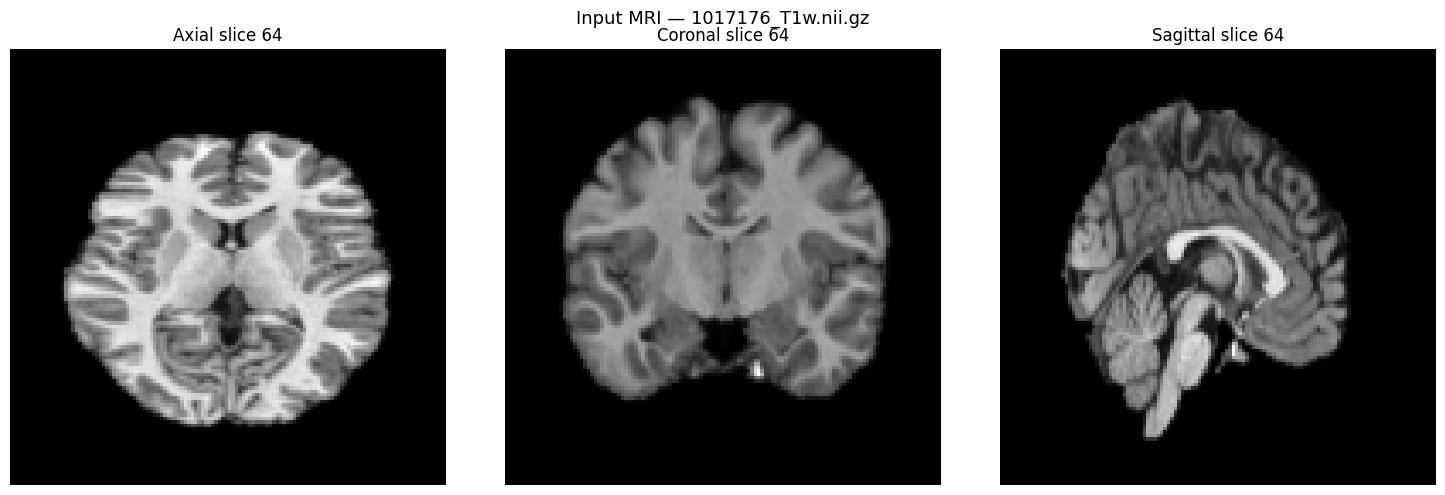

In [5]:
def plot_slices(volume, slice_indices=None):
    if slice_indices is None:
        slice_indices = (volume.shape[0]//2, volume.shape[1]//2, volume.shape[2]//2)
    axial    = volume[:, :, slice_indices[2]]
    coronal  = volume[:, slice_indices[1], :]
    sagittal = volume[slice_indices[0], :, :]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(np.rot90(axial),    cmap="gray"); axes[0].set_title(f'Axial slice {slice_indices[2]}');    axes[0].axis('off')
    axes[1].imshow(np.rot90(coronal),  cmap="gray"); axes[1].set_title(f'Coronal slice {slice_indices[1]}');  axes[1].axis('off')
    axes[2].imshow(np.rot90(sagittal), cmap="gray"); axes[2].set_title(f'Sagittal slice {slice_indices[0]}'); axes[2].axis('off')
    plt.suptitle(f"Input MRI — {os.path.basename(NII_PATH)}", fontsize=13)
    plt.tight_layout()
    plt.show()

plot_slices(raw_data)

import plotly.graph_objects as go

factor  = 2
data_ds = raw_data[::factor, ::factor, ::factor]

fig = go.Figure(data=go.Volume(
    x=np.arange(data_ds.shape[0]).repeat(data_ds.shape[1]*data_ds.shape[2]),
    y=np.tile(np.arange(data_ds.shape[1]).repeat(data_ds.shape[2]), data_ds.shape[0]),
    z=np.tile(np.arange(data_ds.shape[2]), data_ds.shape[0]*data_ds.shape[1]),
    value=data_ds.flatten(),
    opacity=0.1,
    surface_count=25,
    colorscale='Gray'
))
fig.update_layout(
    title=f"3D Volume — {os.path.basename(NII_PATH)}",
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z', aspectmode='data')
)
fig.show()


══════════════════════════════════════════════════
  Prediction  : ADHD  (class 1)
  P(Control)  : 0.4931  (49.3%)
  P(ADHD)     : 0.5069  (50.7%)
  Confidence  : 50.7%
══════════════════════════════════════════════════


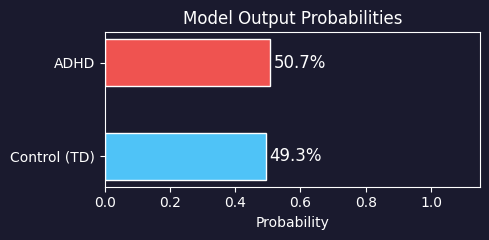

In [6]:
with torch.no_grad():
    logits = model(img_tensor)
    probs  = torch.softmax(logits, dim=1)[0].cpu().numpy()

pred_class = int(np.argmax(probs))
pred_label = "ADHD" if pred_class == 1 else "Control (TD)"
confidence = probs[pred_class] * 100

print("\n" + "═"*50)
print(f"  Prediction  : {pred_label}  (class {pred_class})")
print(f"  P(Control)  : {probs[0]:.4f}  ({probs[0]*100:.1f}%)")
print(f"  P(ADHD)     : {probs[1]:.4f}  ({probs[1]*100:.1f}%)")
print(f"  Confidence  : {confidence:.1f}%")
if TRUE_LABEL is not None:
    true_str = "ADHD" if TRUE_LABEL == 1 else "Control (TD)"
    correct  = "✓ CORRECT" if pred_class == TRUE_LABEL else "✗ WRONG"
    print(f"  True label  : {true_str}  → {correct}")
print("═"*50)

fig, ax = plt.subplots(figsize=(5, 2.5), facecolor="#1a1a2e")
colors = ["#4fc3f7", "#ef5350"]
bars   = ax.barh(["Control (TD)", "ADHD"], probs, color=colors, edgecolor="white", height=0.5)
for bar, p in zip(bars, probs):
    ax.text(p + 0.01, bar.get_y() + bar.get_height()/2,
            f"{p*100:.1f}%", va="center", color="white", fontsize=12)
ax.set_xlim(0, 1.15)
ax.set_xlabel("Probability", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("white")
ax.set_facecolor("#1a1a2e")
ax.set_title("Model Output Probabilities", color="white", fontsize=12)
plt.tight_layout(); plt.show()

In [7]:
print(f"\nComputing saliency ({CHOSEN_MODEL})...")

if CHOSEN_MODEL == "BrainIAC":
    saliency_method = "Attention Rollout"
    extractor       = BrainIACAttentionSaliency(model)
    guided_gradcam  = extractor.generate(img_tensor)
else:
    saliency_method = "Guided Grad-CAM"
    cam             = GradCAM(nn_module=model, target_layers=GRADCAM_LAYER)
    gradcam_map     = cam(x=img_tensor, class_idx=pred_class)[0, 0].cpu().numpy()
    guided_grads    = GuidedBackprop(model).generate(img_tensor, pred_class)
    guided_gradcam  = np.maximum(guided_grads * gradcam_map, 0)
    guided_gradcam /= (guided_gradcam.max() + 1e-8)

valid = guided_gradcam[guided_gradcam > 0]
q50   = np.median(valid) if len(valid) > 0 else 0.0
mask  = (guided_gradcam > q50).astype(float)
print(f"Saliency computed ✓  |  threshold q50 = {q50:.4f}  |  "
      f"salient voxels = {int(mask.sum()):,}")


Computing saliency (BrainIAC)...
Saliency computed ✓  |  threshold q50 = 0.1400  |  salient voxels = 418,440



Computing saliency (BrainIAC)...


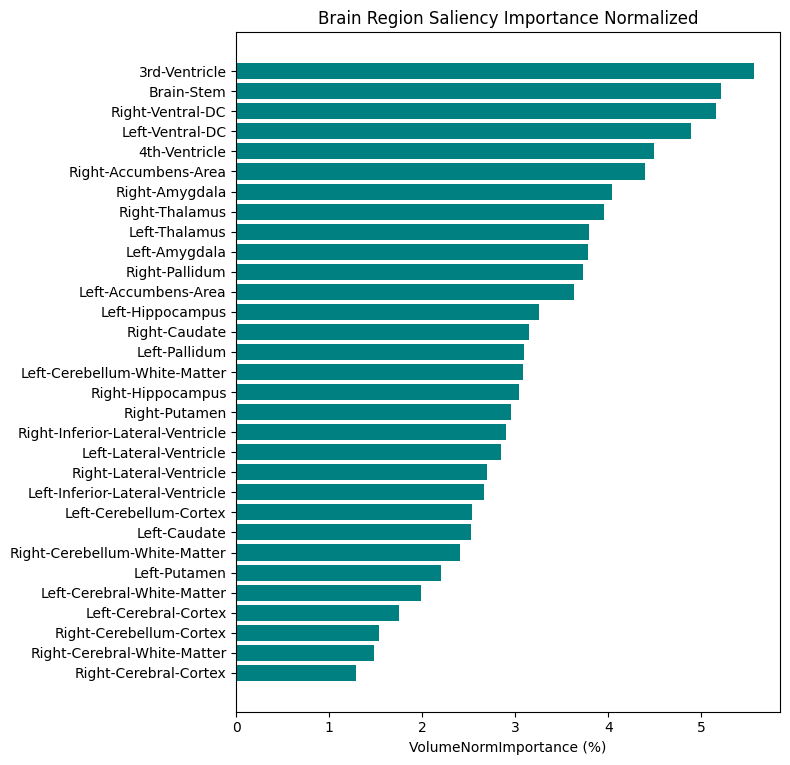

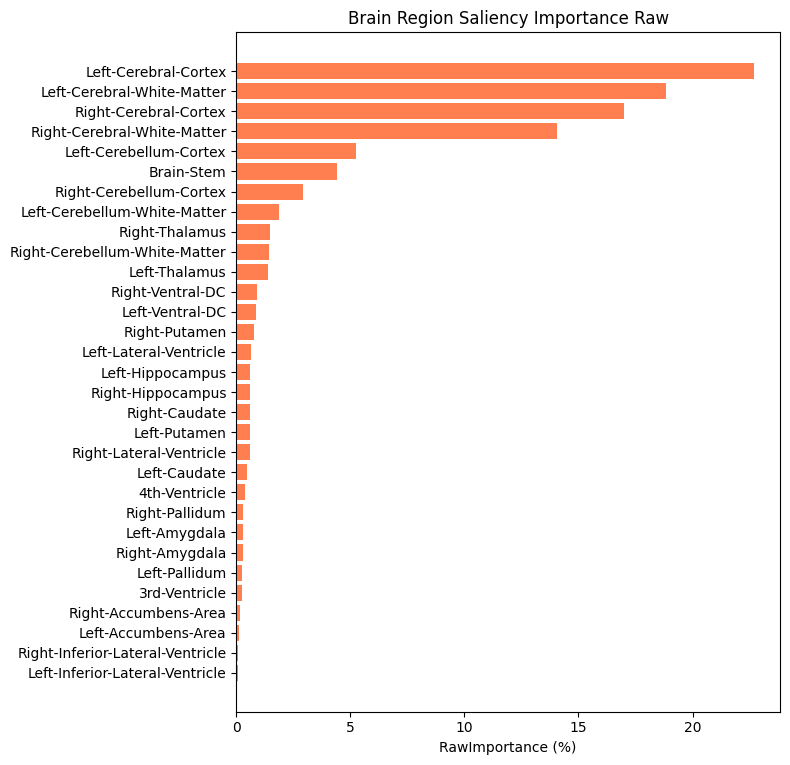

Region saliency analysis complete ✓


In [8]:
print(f"\nComputing saliency ({CHOSEN_MODEL})...")

if CHOSEN_MODEL == "BrainIAC":
    saliency_method = "Attention Rollout"
    extractor = BrainIACAttentionSaliency(model)
    guided_gradcam = extractor.generate(img_tensor)

else:
    saliency_method = "Guided Grad-CAM"

    cam = GradCAM(
        nn_module=model,
        target_layers=GRADCAM_LAYER
    )

    gradcam_map = cam(
        x=img_tensor,
        class_idx=pred_class
    )[0, 0].cpu().numpy()

    guided_grads = GuidedBackprop(model).generate(
        img_tensor,
        pred_class
    )

    guided_gradcam = np.maximum(
        guided_grads * gradcam_map,
        0
    )

    guided_gradcam /= (
        guided_gradcam.max() + 1e-8
    )

mask = (guided_gradcam > np.median(guided_gradcam[guided_gradcam > 0])).astype(float)

proc_vol = img_tensor[0, 0].detach().cpu().numpy()

subject_num = os.path.basename(NII_PATH).split("_")[0]
subject_id = f"sub-{subject_num}"

seg_path = rf"..\ADHD_BIDS\derivatives\labels\{subject_id}\{subject_num}_desc-synthseg_dseg.nii.gz"

seg_img = nib.load(seg_path)
seg_data = seg_img.get_fdata()

if seg_data.shape != guided_gradcam.shape:

    scale_factors = (
        guided_gradcam.shape[0] / seg_data.shape[0],
        guided_gradcam.shape[1] / seg_data.shape[1],
        guided_gradcam.shape[2] / seg_data.shape[2],
    )

    seg_data = zoom(seg_data, scale_factors, order=0)

ID_TO_LABEL = {
    2: "Left-Cerebral-White-Matter",
    3: "Left-Cerebral-Cortex",
    4: "Left-Lateral-Ventricle",
    5: "Left-Inferior-Lateral-Ventricle",
    7: "Left-Cerebellum-White-Matter",
    8: "Left-Cerebellum-Cortex",
    10: "Left-Thalamus",
    11: "Left-Caudate",
    12: "Left-Putamen",
    13: "Left-Pallidum",
    17: "Left-Hippocampus",
    18: "Left-Amygdala",
    26: "Left-Accumbens-Area",
    28: "Left-Ventral-DC",
    41: "Right-Cerebral-White-Matter",
    42: "Right-Cerebral-Cortex",
    43: "Right-Lateral-Ventricle",
    44: "Right-Inferior-Lateral-Ventricle",
    46: "Right-Cerebellum-White-Matter",
    47: "Right-Cerebellum-Cortex",
    49: "Right-Thalamus",
    50: "Right-Caudate",
    51: "Right-Putamen",
    52: "Right-Pallidum",
    53: "Right-Hippocampus",
    54: "Right-Amygdala",
    58: "Right-Accumbens-Area",
    60: "Right-Ventral-DC",
    14: "3rd-Ventricle",
    15: "4th-Ventricle",
    16: "Brain-Stem"
}

rows = []

for label_id, region_name in ID_TO_LABEL.items():

    region_mask = (seg_data == label_id)

    if region_mask.sum() == 0:
        continue

    raw_importance = guided_gradcam[region_mask].sum()

    norm_importance = raw_importance / (region_mask.sum() + 1e-8)

    rows.append({
        "Region": region_name,
        "RawImportance": raw_importance,
        "VolumeNormImportance": norm_importance
    })

import pandas as pd

df = pd.DataFrame(rows)

df["RawImportance%"] = df["RawImportance"] / (df["RawImportance"].sum() + 1e-8) * 100
df["VolumeNormImportance%"] = df["VolumeNormImportance"] / (df["VolumeNormImportance"].sum() + 1e-8) * 100

df_plot = df.sort_values(by="VolumeNormImportance%", ascending=True)

plt.figure(figsize=(8, max(4, 0.25 * len(df_plot))))
plt.barh(df_plot["Region"], df_plot["VolumeNormImportance%"], color="teal")
plt.xlabel("VolumeNormImportance (%)")
plt.title("Brain Region Saliency Importance Normalized")
plt.tight_layout()
plt.show()

df_plot_raw = df.sort_values(by="RawImportance%", ascending=True)

plt.figure(figsize=(8, max(4, 0.25 * len(df_plot_raw))))
plt.barh(df_plot_raw["Region"], df_plot_raw["RawImportance%"], color="coral")
plt.xlabel("RawImportance (%)")
plt.title("Brain Region Saliency Importance Raw")
plt.tight_layout()
plt.show()

print("Region saliency analysis complete ✓")